# DTLZ3 Results

In [1]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 10
NPOP = 800
NGEN = 600
NOBJ = 4 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz3_segura = partial(benchmarks.dtlz3, obj=NOBJ)
toolbox = build_toolbox(func_dtlz3_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 40
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


(9.892483330339671e-32, 0.0, 6.12331190788352e-17, 1.0000127240191716)
(6.123853059696189e-17, 0.0, 0.0, 1.0001011008169627)
(1.0016435388074498, 0.0, 0.0, 0.0)
(2.2958728518928992e-49, 3.74944490687662e-33, 6.123308221582141e-17, 1.00001212200047)
(0.00015977799933811858, 0.0, 106.8395547089108, 0.00013582698159677473)
(1.8751879835771509e-06, 70.3596473956507, 0.0, 0.0)
(6.123308171255124e-17, 1.0000121137814446, 0.0, 8.24870212525436e-17)
(7.230498301844786e-05, 0.0, 51.93366508256528, 0.01165621875756223)
(0.9413590636776423, 0.08858669065463504, 0.09702427796957072, 0.3108497240851549)
(1.827589206394842e-15, 2.3916285681905926e-22, 29.84679676895079, 0.0)
(0.8245548223452531, 0.09808020896624435, 2.462005050352826e-05, 0.5572388835883031)
(0.8415055374476516, 0.5241275951341599, 0.00022581865192706756, 0.13108886760787378)
(3.749444864464012e-33, 6.123308152317096e-17, 1.0000121106886297, 0.0)
(0.9568184940109374, 0.07004006862521057, 0.09844656864038484, 0.2644745277561292)
(0.1

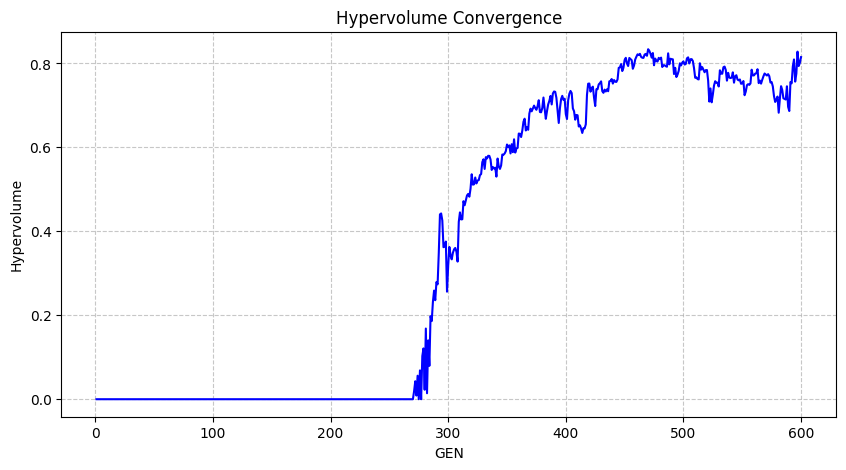

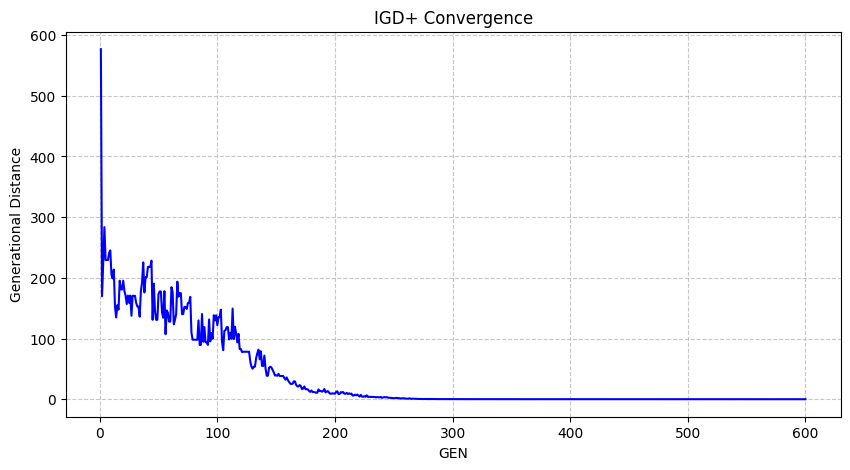

In [ ]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()